# Unit 4 Project
After understanding how neural networks work, implementing some basic architectures using deep learning frameworks, and learning about some advanced techniques to help enhance our neural networks' models results, it's time to apply what you learned! So let's start

## Project Overview 
In this project, you will build a neural network model to classify images from CIFAR 10 dataset. 

The CIFAR-10 dataset consists of 60000 32x32 color images of 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class. [source](https://www.cs.toronto.edu/~kriz/cifar.html)

Unlike the previous projects, there will be no code cells to fill, the only task you have is to build the best possible model using the techniques you learned about in this unit. But we will guide you with some directives.

You will have enough guidance throughout the project and your work will be reviewed and graded by a teacher assistant. You can also reach out to the TA via slack whenever you feel you are stuck.

## Some guidelines
- Please use text cells to write the questions' answers in a good way.
- Don't forget to save the different models you tested so you will be able to report the different results you got and the impact of the different techniques you tested later.

## Getting started
- In case you don't have a GPU, it is recommended that you use google colab. Start by cloning this repository, then open [google colab](https://colab.research.google.com/), click on File > Upload notebook, and finally upload the ```.ipynb``` file from the repository you have just cloned! Don't forget to change the runtime to GPU. If you want to work in your local environment just open it using jupyter notebook.



## Dataset 

1.   Load the dataset (**hint**: it's available here https://keras.io/api/datasets/)
2.   Display few images of each class.



In [26]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import keras
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random


In [27]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # no-op if no GPU, harmless to include
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [28]:
# Load the data and split into train, test and validation set
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


In [29]:
! pip install matplotlib



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


###  Display 3 images of each class:

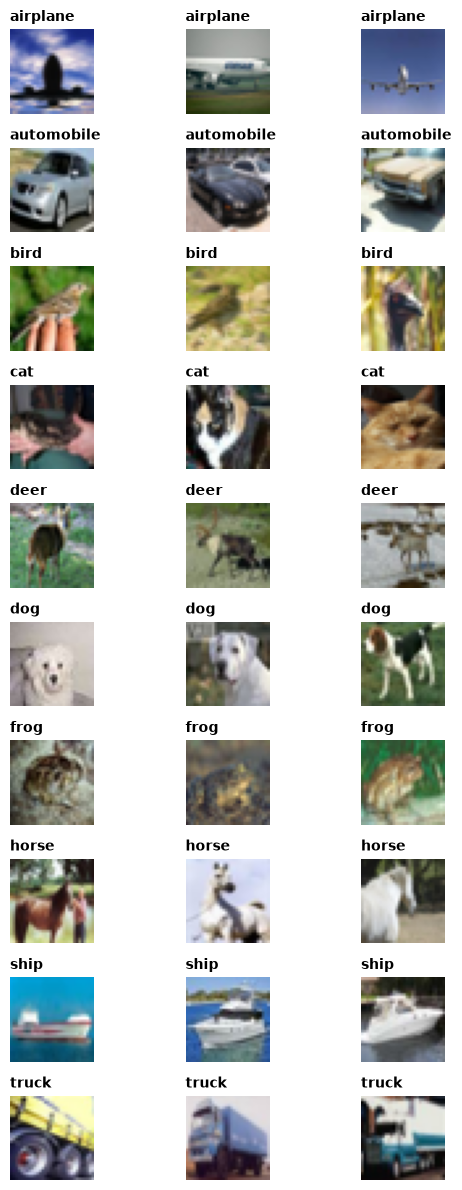

In [30]:

import matplotlib.pyplot as plt
import numpy as np

y_train = y_train.flatten()  # Flatten to 1D array

# Define official labels
labels = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

# Grid configuration: 10 classes (rows) x 3 examples (columns)
num_classes = 10
num_samples = 3
fig, axes = plt.subplots(num_classes, num_samples, figsize=(6, 12))

# Loop through each class and find samples
for class_idx in range(num_classes):
    # Find all indices belonging to the current class
    indices = np.where(y_train == class_idx)[0][:num_samples]

    for sample_idx, img_idx in enumerate(indices):
        ax = axes[class_idx, sample_idx]
        ax.imshow(x_train[img_idx])
        ax.axis("off")
        ax.set_title(labels[class_idx], loc="left", fontsize=10, weight="bold")

plt.tight_layout()
plt.show()


### Create tensors and data loaders

In [31]:
X_train = torch.tensor(x_train, dtype=torch.float32) / 255
X_val = torch.tensor(x_val, dtype=torch.float32) / 255
X_test = torch.tensor(x_test, dtype=torch.float32) / 255

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


## Baseline Model

1.   Build a basline model using only dense layers, activation function of your choice, and the adapted cost function for this problem.
2.   Train and evaluate your model
3.   Analyze the result



### Train function
Adam optimizer, Cross Entropy Loss function

In [32]:
results_summary = {}

import torch

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

def train_model(model, train_loader, val_loader, test_loader,
                device=None, optimizer_name="adam", lr=1e-3, l2=0.0, epochs=30,
                use_early_stopping=False, patience=5,
                model_name=None):

    
    if device is None:
        device = get_device()
    else:
        device = torch.device(device)

    model = model.to(device)
    
    print(f"Training on: {device}")

    # --- OPTIMIZER SELECTION 
    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=l2)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=l2)
    else:
        raise ValueError(f"Unknown optimizer_name: {optimizer_name}")

    loss_fn = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # --- TRAINING LOOP ---
        model.train()
        running_loss = 0.0
        train_correct = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).long().flatten()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
        train_loss = running_loss / len(train_loader)
        train_accuracy = train_correct / len(train_loader.dataset)

        # --- VALIDATION LOOP ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).long().flatten()
                outputs = model(inputs)
                val_loss += loss_fn(outputs, labels).item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader)
        val_accuracy = val_correct / len(val_loader.dataset)

        # --- RECORD HISTORY (this is the part that was missing) ---
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_accuracy)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

        # --- EARLY STOPPING ---
        if use_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                if best_state is not None:
                    model.load_state_dict(best_state)
                break

    # --- TEST LOOP ---
    model.eval()
    test_loss, test_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device).long().flatten()
            outputs = model(inputs)
            test_loss += loss_fn(outputs, labels).item()
            test_correct += (outputs.argmax(1) == labels).sum().item()
    test_loss /= len(test_loader)
    test_accuracy = test_correct / len(test_loader.dataset)
    print(f"\nFinal Test Loss: {test_loss:.4f} | Final Test Acc: {test_accuracy:.4f}")

    # --- STORE FOR COMPARISON ---
    name = model_name or model.__class__.__name__
    results_summary[name] = {
        "train_loss": history["train_loss"][-1], "train_acc": history["train_acc"][-1],
        "val_loss": history["val_loss"][-1],     "val_acc": history["val_acc"][-1],
        "test_loss": test_loss,                  "test_acc": test_accuracy,
        "epochs_trained": epoch + 1,
    }
    return model

### 1. Baseline Model
3 layers, activation function: ReLU, 

In [33]:

class CIFAR10BaselineModel(nn.Module):
    def __init__(self):
        super(CIFAR10BaselineModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.act1 =nn.ReLU()
        self.fc2 = nn.Linear(512,128)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.fc3(x)
        return x


In [34]:

set_seed(42)
model = CIFAR10BaselineModel()
train_model(model, train_loader, val_loader, test_loader, optimizer_name="adam", model_name="Baseline Model")


Training on: mps
Epoch 01 | Train Loss: 1.8829, Train Acc: 0.3126 | Val Loss: 1.7352, Val Acc: 0.3774
Epoch 02 | Train Loss: 1.7046, Train Acc: 0.3867 | Val Loss: 1.6864, Val Acc: 0.3917
Epoch 03 | Train Loss: 1.6228, Train Acc: 0.4154 | Val Loss: 1.6006, Val Acc: 0.4355
Epoch 04 | Train Loss: 1.5626, Train Acc: 0.4391 | Val Loss: 1.5706, Val Acc: 0.4370
Epoch 05 | Train Loss: 1.5211, Train Acc: 0.4544 | Val Loss: 1.5384, Val Acc: 0.4551
Epoch 06 | Train Loss: 1.4847, Train Acc: 0.4699 | Val Loss: 1.5312, Val Acc: 0.4570
Epoch 07 | Train Loss: 1.4622, Train Acc: 0.4787 | Val Loss: 1.5118, Val Acc: 0.4658
Epoch 08 | Train Loss: 1.4393, Train Acc: 0.4841 | Val Loss: 1.4801, Val Acc: 0.4796
Epoch 09 | Train Loss: 1.4188, Train Acc: 0.4901 | Val Loss: 1.4995, Val Acc: 0.4668
Epoch 10 | Train Loss: 1.3992, Train Acc: 0.4992 | Val Loss: 1.4932, Val Acc: 0.4770
Epoch 11 | Train Loss: 1.3798, Train Acc: 0.5061 | Val Loss: 1.4723, Val Acc: 0.4794
Epoch 12 | Train Loss: 1.3660, Train Acc: 0.5118

CIFAR10BaselineModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (act1): ReLU()
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (act2): ReLU()
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

## 2. Accelerating the training

1.   Add batch normalization layers to your network in order to accelerate the training. Start with adding batch norm layer before each of your activation layers.
2.   Analyze the new results
3.   Change the position of the batch norm layers so they will be after the activation layers. Compare the results.
   



### 2.1 Accelerating the training - add batch normalization (BEFORE activation function)

In [35]:


class CIFAR10Experiment1(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment1, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 =nn.ReLU()
        self.fc2 = nn.Linear(512,128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.fc3(x)
        return x
    
set_seed(42)

model_1 = CIFAR10Experiment1()
train_model(model_1, train_loader, val_loader, test_loader, optimizer_name="adam", model_name="Batch Normalization (before ReLU)")

Training on: mps
Epoch 01 | Train Loss: 1.6556, Train Acc: 0.4073 | Val Loss: 1.5079, Val Acc: 0.4643
Epoch 02 | Train Loss: 1.4543, Train Acc: 0.4829 | Val Loss: 1.5322, Val Acc: 0.4526
Epoch 03 | Train Loss: 1.3534, Train Acc: 0.5181 | Val Loss: 1.4528, Val Acc: 0.4800
Epoch 04 | Train Loss: 1.2743, Train Acc: 0.5462 | Val Loss: 1.4408, Val Acc: 0.4949
Epoch 05 | Train Loss: 1.2127, Train Acc: 0.5689 | Val Loss: 1.4082, Val Acc: 0.5079
Epoch 06 | Train Loss: 1.1516, Train Acc: 0.5882 | Val Loss: 1.4176, Val Acc: 0.4963
Epoch 07 | Train Loss: 1.0942, Train Acc: 0.6120 | Val Loss: 1.3689, Val Acc: 0.5259
Epoch 08 | Train Loss: 1.0383, Train Acc: 0.6325 | Val Loss: 1.3839, Val Acc: 0.5298
Epoch 09 | Train Loss: 0.9849, Train Acc: 0.6508 | Val Loss: 1.3607, Val Acc: 0.5332
Epoch 10 | Train Loss: 0.9358, Train Acc: 0.6665 | Val Loss: 1.4524, Val Acc: 0.5293
Epoch 11 | Train Loss: 0.8906, Train Acc: 0.6850 | Val Loss: 1.5811, Val Acc: 0.4998
Epoch 12 | Train Loss: 0.8443, Train Acc: 0.6993

CIFAR10Experiment1(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 2.2 Accelerating the training - adding batch normalization (AFTER activation function)

In [36]:

class CIFAR10Experiment2(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment2, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.act1 =nn.ReLU()
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512,128)
        self.act2 = nn.ReLU()
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act1(x)
        x = self.bn1(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.bn2(x)
        x = self.fc3(x)
        return x

set_seed(42)
model_2 = CIFAR10Experiment2()

train_model(model_2, train_loader, val_loader, test_loader, optimizer_name="adam", model_name="Batch Normalization (after ReLU)")

Training on: mps
Epoch 01 | Train Loss: 1.7552, Train Acc: 0.3735 | Val Loss: 1.6770, Val Acc: 0.4141
Epoch 02 | Train Loss: 1.6043, Train Acc: 0.4322 | Val Loss: 1.6908, Val Acc: 0.4316
Epoch 03 | Train Loss: 1.5393, Train Acc: 0.4522 | Val Loss: 1.5956, Val Acc: 0.4551
Epoch 04 | Train Loss: 1.4948, Train Acc: 0.4698 | Val Loss: 1.7164, Val Acc: 0.4528
Epoch 05 | Train Loss: 1.4637, Train Acc: 0.4806 | Val Loss: 1.5990, Val Acc: 0.4725
Epoch 06 | Train Loss: 1.4324, Train Acc: 0.4898 | Val Loss: 1.5585, Val Acc: 0.4829
Epoch 07 | Train Loss: 1.4097, Train Acc: 0.4984 | Val Loss: 1.5258, Val Acc: 0.4775
Epoch 08 | Train Loss: 1.3813, Train Acc: 0.5094 | Val Loss: 1.5338, Val Acc: 0.4855
Epoch 09 | Train Loss: 1.3683, Train Acc: 0.5150 | Val Loss: 1.5649, Val Acc: 0.4735
Epoch 10 | Train Loss: 1.3594, Train Acc: 0.5163 | Val Loss: 1.5279, Val Acc: 0.5016
Epoch 11 | Train Loss: 1.3418, Train Acc: 0.5234 | Val Loss: 1.4957, Val Acc: 0.5031
Epoch 12 | Train Loss: 1.3271, Train Acc: 0.5288

CIFAR10Experiment2(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (act1): ReLU()
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (act2): ReLU()
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

## 3. Reducing the overfitting 
1.   Apply the dropout technique to reduce the overfitting your model is suffering from
2.   Try different dropout rates 

### 3.1 Reducing overfitting - add dropout 0.3

In [37]:
# Your code here

class CIFAR10Experiment3(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment3, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512,128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

set_seed(42)
model_3 = CIFAR10Experiment3()

train_model(model_3, train_loader, val_loader,  test_loader, optimizer_name="adam", model_name="Batch Norm (before ReLU)+ Dropout 0.3")

Training on: mps
Epoch 01 | Train Loss: 1.7500, Train Acc: 0.3714 | Val Loss: 1.5606, Val Acc: 0.4520
Epoch 02 | Train Loss: 1.5810, Train Acc: 0.4375 | Val Loss: 1.5004, Val Acc: 0.4621
Epoch 03 | Train Loss: 1.5150, Train Acc: 0.4572 | Val Loss: 1.4369, Val Acc: 0.4923
Epoch 04 | Train Loss: 1.4632, Train Acc: 0.4784 | Val Loss: 1.4545, Val Acc: 0.4858
Epoch 05 | Train Loss: 1.4218, Train Acc: 0.4956 | Val Loss: 1.3828, Val Acc: 0.5076
Epoch 06 | Train Loss: 1.3875, Train Acc: 0.5036 | Val Loss: 1.3684, Val Acc: 0.5165
Epoch 07 | Train Loss: 1.3598, Train Acc: 0.5160 | Val Loss: 1.3420, Val Acc: 0.5225
Epoch 08 | Train Loss: 1.3292, Train Acc: 0.5267 | Val Loss: 1.3272, Val Acc: 0.5316
Epoch 09 | Train Loss: 1.3064, Train Acc: 0.5361 | Val Loss: 1.3481, Val Acc: 0.5259
Epoch 10 | Train Loss: 1.2706, Train Acc: 0.5467 | Val Loss: 1.2866, Val Acc: 0.5483
Epoch 11 | Train Loss: 1.2566, Train Acc: 0.5535 | Val Loss: 1.3032, Val Acc: 0.5374
Epoch 12 | Train Loss: 1.2374, Train Acc: 0.5612

CIFAR10Experiment3(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 3.2 Reducing overfitting - adding dropout 0.4

In [38]:
# Your code here

class CIFAR10Experiment4(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment4, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512,128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

set_seed(42)
model_4 = CIFAR10Experiment4()

train_model(model_4, train_loader, val_loader,  test_loader, optimizer_name="adam", model_name="Batch Norm(beforeReLU) + Dropout 0.4")

Training on: mps
Epoch 01 | Train Loss: 1.7924, Train Acc: 0.3555 | Val Loss: 1.5839, Val Acc: 0.4460
Epoch 02 | Train Loss: 1.6332, Train Acc: 0.4171 | Val Loss: 1.5294, Val Acc: 0.4509
Epoch 03 | Train Loss: 1.5669, Train Acc: 0.4390 | Val Loss: 1.4548, Val Acc: 0.4875
Epoch 04 | Train Loss: 1.5219, Train Acc: 0.4547 | Val Loss: 1.4567, Val Acc: 0.4873
Epoch 05 | Train Loss: 1.4897, Train Acc: 0.4703 | Val Loss: 1.4193, Val Acc: 0.4937
Epoch 06 | Train Loss: 1.4568, Train Acc: 0.4798 | Val Loss: 1.3855, Val Acc: 0.5148
Epoch 07 | Train Loss: 1.4350, Train Acc: 0.4866 | Val Loss: 1.3552, Val Acc: 0.5181
Epoch 08 | Train Loss: 1.4064, Train Acc: 0.4998 | Val Loss: 1.3593, Val Acc: 0.5225
Epoch 09 | Train Loss: 1.3812, Train Acc: 0.5086 | Val Loss: 1.3377, Val Acc: 0.5273
Epoch 10 | Train Loss: 1.3541, Train Acc: 0.5170 | Val Loss: 1.3237, Val Acc: 0.5357
Epoch 11 | Train Loss: 1.3431, Train Acc: 0.5219 | Val Loss: 1.3156, Val Acc: 0.5363
Epoch 12 | Train Loss: 1.3326, Train Acc: 0.5267

CIFAR10Experiment4(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 3.3 Reducing overfitting - adding dropout 0.5

In [39]:
# Your code here

class CIFAR10Experiment5(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment5, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512,128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

set_seed(42)
model_5 = CIFAR10Experiment5()

train_model(model_5, train_loader, val_loader,  test_loader, optimizer_name="adam", model_name="Batch Norm(beforeReLU) + Dropout 0.5")

Training on: mps
Epoch 01 | Train Loss: 1.8442, Train Acc: 0.3351 | Val Loss: 1.6514, Val Acc: 0.4136
Epoch 02 | Train Loss: 1.6904, Train Acc: 0.3973 | Val Loss: 1.5754, Val Acc: 0.4349
Epoch 03 | Train Loss: 1.6326, Train Acc: 0.4152 | Val Loss: 1.5217, Val Acc: 0.4623
Epoch 04 | Train Loss: 1.5914, Train Acc: 0.4324 | Val Loss: 1.4795, Val Acc: 0.4793
Epoch 05 | Train Loss: 1.5638, Train Acc: 0.4401 | Val Loss: 1.4458, Val Acc: 0.4893
Epoch 06 | Train Loss: 1.5304, Train Acc: 0.4540 | Val Loss: 1.4166, Val Acc: 0.5059
Epoch 07 | Train Loss: 1.5097, Train Acc: 0.4624 | Val Loss: 1.4098, Val Acc: 0.4982
Epoch 08 | Train Loss: 1.4880, Train Acc: 0.4709 | Val Loss: 1.4028, Val Acc: 0.5019
Epoch 09 | Train Loss: 1.4691, Train Acc: 0.4752 | Val Loss: 1.3950, Val Acc: 0.5124
Epoch 10 | Train Loss: 1.4465, Train Acc: 0.4836 | Val Loss: 1.3566, Val Acc: 0.5195
Epoch 11 | Train Loss: 1.4375, Train Acc: 0.4867 | Val Loss: 1.3518, Val Acc: 0.5265
Epoch 12 | Train Loss: 1.4212, Train Acc: 0.4944

CIFAR10Experiment5(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

## 4. Trying different model's parameters
1. Try changing the number of layers, the number of hidden neurons in each layer, the activation functions, the weight initialization method...
2. Compare the results you got for each evaluated model.

### 4.1 Different model parameters - 1 additional layer

In [40]:
# Your code here
# 1 additional layer
class CIFAR10Experiment6(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment6, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.act3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.5)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)
        x = self.fc4(x)
        return x


set_seed(42)
model_6 = CIFAR10Experiment6()

train_model(model_6, train_loader, val_loader,  test_loader, optimizer_name="adam", model_name="Batch Norm(before ReLU) + Dropout 0.5 + Extra Layer")

Training on: mps
Epoch 01 | Train Loss: 1.9491, Train Acc: 0.2894 | Val Loss: 1.7049, Val Acc: 0.3973
Epoch 02 | Train Loss: 1.7913, Train Acc: 0.3559 | Val Loss: 1.6411, Val Acc: 0.4173
Epoch 03 | Train Loss: 1.7437, Train Acc: 0.3748 | Val Loss: 1.5788, Val Acc: 0.4424
Epoch 04 | Train Loss: 1.7034, Train Acc: 0.3940 | Val Loss: 1.5562, Val Acc: 0.4501
Epoch 05 | Train Loss: 1.6714, Train Acc: 0.4030 | Val Loss: 1.5304, Val Acc: 0.4578
Epoch 06 | Train Loss: 1.6437, Train Acc: 0.4175 | Val Loss: 1.5005, Val Acc: 0.4713
Epoch 07 | Train Loss: 1.6243, Train Acc: 0.4240 | Val Loss: 1.4678, Val Acc: 0.4771
Epoch 08 | Train Loss: 1.6016, Train Acc: 0.4319 | Val Loss: 1.4657, Val Acc: 0.4783
Epoch 09 | Train Loss: 1.5787, Train Acc: 0.4384 | Val Loss: 1.4269, Val Acc: 0.4968
Epoch 10 | Train Loss: 1.5603, Train Acc: 0.4484 | Val Loss: 1.4102, Val Acc: 0.5060
Epoch 11 | Train Loss: 1.5422, Train Acc: 0.4557 | Val Loss: 1.4001, Val Acc: 0.4980
Epoch 12 | Train Loss: 1.5318, Train Acc: 0.4620

CIFAR10Experiment6(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act3): ReLU()
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)

### 4.2 Different model parameters: additional layer + different num of hidden neurons

In [41]:
# Your code here
# 1 additional layer , change of num of hidden neurons

class CIFAR10Experiment7(nn.Module):
    def __init__(self):
        super(CIFAR10Experiment7, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.act3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.5)
        self.fc4 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)
        x = self.fc4(x)
        return x


set_seed(42)
model_7 = CIFAR10Experiment7()

train_model(model_7, train_loader, val_loader,  test_loader, optimizer_name="adam", model_name="Batch Norm + Dropout 0.5 + Extra Layer + Changed Hidden Neurons")

Training on: mps
Epoch 01 | Train Loss: 2.0068, Train Acc: 0.2663 | Val Loss: 1.7827, Val Acc: 0.3709
Epoch 02 | Train Loss: 1.8694, Train Acc: 0.3222 | Val Loss: 1.7131, Val Acc: 0.3930
Epoch 03 | Train Loss: 1.8193, Train Acc: 0.3453 | Val Loss: 1.6919, Val Acc: 0.4003
Epoch 04 | Train Loss: 1.7883, Train Acc: 0.3551 | Val Loss: 1.6211, Val Acc: 0.4276
Epoch 05 | Train Loss: 1.7627, Train Acc: 0.3656 | Val Loss: 1.5779, Val Acc: 0.4458
Epoch 06 | Train Loss: 1.7362, Train Acc: 0.3792 | Val Loss: 1.5691, Val Acc: 0.4532
Epoch 07 | Train Loss: 1.7141, Train Acc: 0.3874 | Val Loss: 1.5337, Val Acc: 0.4637
Epoch 08 | Train Loss: 1.6994, Train Acc: 0.3948 | Val Loss: 1.5034, Val Acc: 0.4665
Epoch 09 | Train Loss: 1.6894, Train Acc: 0.3967 | Val Loss: 1.5100, Val Acc: 0.4695
Epoch 10 | Train Loss: 1.6727, Train Acc: 0.4031 | Val Loss: 1.4961, Val Acc: 0.4704
Epoch 11 | Train Loss: 1.6562, Train Acc: 0.4117 | Val Loss: 1.4840, Val Acc: 0.4774
Epoch 12 | Train Loss: 1.6483, Train Acc: 0.4140

CIFAR10Experiment7(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act3): ReLU()
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=32, out_features=10, bias=True)
)

## 5. Few more experiments to go

1.   **Exploring more regularization techniques:** Try at least 2 regularization techniques separately and combined.  A non-exhaustive list of regularization techniques you can test


> * L1 and L2 regularization
* Early stopping
* Data augmentation
* Decreasing the complexity of the model

2.   **Hyperparameters' tuning:** Try to tune the learning parameters using the tuning strategies we learned about:

> * Learning rate
* Mini-batch size
* The optimizer and its parameters

3. Analyze the impact of each of the applied techniques. What were the most effective ones? What were the hypeparameters that affects the results the most?


### 5.1 Adding regularization - early stopping

In [42]:

model_8 = CIFAR10Experiment5()
train_model(model_8, train_loader, val_loader, test_loader, optimizer_name="adam", epochs = 100, use_early_stopping=True, patience=5, model_name="Batch Norm + Dropout 0.5 + Early Stopping")


Training on: mps
Epoch 01 | Train Loss: 1.8438, Train Acc: 0.3355 | Val Loss: 1.6467, Val Acc: 0.4219
Epoch 02 | Train Loss: 1.6912, Train Acc: 0.3929 | Val Loss: 1.5655, Val Acc: 0.4498
Epoch 03 | Train Loss: 1.6318, Train Acc: 0.4155 | Val Loss: 1.5068, Val Acc: 0.4685
Epoch 04 | Train Loss: 1.5895, Train Acc: 0.4303 | Val Loss: 1.4695, Val Acc: 0.4829
Epoch 05 | Train Loss: 1.5610, Train Acc: 0.4415 | Val Loss: 1.4863, Val Acc: 0.4807
Epoch 06 | Train Loss: 1.5371, Train Acc: 0.4509 | Val Loss: 1.4168, Val Acc: 0.4968
Epoch 07 | Train Loss: 1.5127, Train Acc: 0.4608 | Val Loss: 1.4176, Val Acc: 0.5025
Epoch 08 | Train Loss: 1.4877, Train Acc: 0.4706 | Val Loss: 1.4121, Val Acc: 0.5070
Epoch 09 | Train Loss: 1.4632, Train Acc: 0.4781 | Val Loss: 1.3956, Val Acc: 0.5072
Epoch 10 | Train Loss: 1.4565, Train Acc: 0.4816 | Val Loss: 1.3599, Val Acc: 0.5141
Epoch 11 | Train Loss: 1.4324, Train Acc: 0.4893 | Val Loss: 1.3439, Val Acc: 0.5209
Epoch 12 | Train Loss: 1.4195, Train Acc: 0.4940

CIFAR10Experiment5(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 5.2 Adding regularization - early stopping + L2 regularization (AdamW optimizer)

In [43]:
set_seed(42)

model_9 = CIFAR10Experiment5()


train_model(model_9, train_loader, val_loader, test_loader, optimizer_name="adamw", epochs=100, l2=1e-4, use_early_stopping=True, patience=5, model_name="Batch Norm + Dropout 0.5 + L2 Regularization")


Training on: mps
Epoch 01 | Train Loss: 1.8433, Train Acc: 0.3332 | Val Loss: 1.6344, Val Acc: 0.4203
Epoch 02 | Train Loss: 1.6885, Train Acc: 0.3967 | Val Loss: 1.5840, Val Acc: 0.4312
Epoch 03 | Train Loss: 1.6285, Train Acc: 0.4152 | Val Loss: 1.5109, Val Acc: 0.4653
Epoch 04 | Train Loss: 1.5904, Train Acc: 0.4330 | Val Loss: 1.4933, Val Acc: 0.4668
Epoch 05 | Train Loss: 1.5605, Train Acc: 0.4431 | Val Loss: 1.4396, Val Acc: 0.4859
Epoch 06 | Train Loss: 1.5293, Train Acc: 0.4548 | Val Loss: 1.4426, Val Acc: 0.4942
Epoch 07 | Train Loss: 1.5074, Train Acc: 0.4621 | Val Loss: 1.4011, Val Acc: 0.5052
Epoch 08 | Train Loss: 1.4831, Train Acc: 0.4733 | Val Loss: 1.3900, Val Acc: 0.5081
Epoch 09 | Train Loss: 1.4640, Train Acc: 0.4777 | Val Loss: 1.3742, Val Acc: 0.5146
Epoch 10 | Train Loss: 1.4428, Train Acc: 0.4862 | Val Loss: 1.3493, Val Acc: 0.5194
Epoch 11 | Train Loss: 1.4341, Train Acc: 0.4859 | Val Loss: 1.3492, Val Acc: 0.5206
Epoch 12 | Train Loss: 1.4188, Train Acc: 0.4957

CIFAR10Experiment5(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 5.3 Adding Data Augumentation

In [44]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
])

class CIFAR10AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].clone()
        label = self.labels[idx]

        # torchvision expects CHW; CIFAR-10 tensors here are HWC
        image = image.permute(2, 0, 1)

        if self.transform:
            image = self.transform(image)

        image = image.permute(1, 2, 0)  # back to HWC, matches val_loader layout
        return image, label

augmented_train_dataset = CIFAR10AugmentedDataset(
    X_train.clone(),
    y_train.clone(),
    transform=train_transform
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=32,
    shuffle=True,
)

class CIFAR10AugmentedModel(nn.Module):
    def __init__(self):
        super(CIFAR10AugmentedModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x
    
set_seed(42)
model_10 = CIFAR10AugmentedModel()

train_model(
    model_10,
    augmented_train_loader,
    val_loader,
    test_loader,
    optimizer_name="adam",
    epochs=100,
    use_early_stopping=True,
    patience=3,
    model_name="Batch Norm + Dropout 0.5 + Early Stopping + Data Augmentation"
)

Training on: mps
Epoch 01 | Train Loss: 1.9805, Train Acc: 0.2717 | Val Loss: 1.7687, Val Acc: 0.3630
Epoch 02 | Train Loss: 1.8619, Train Acc: 0.3227 | Val Loss: 1.6853, Val Acc: 0.4013
Epoch 03 | Train Loss: 1.8246, Train Acc: 0.3365 | Val Loss: 1.6534, Val Acc: 0.4009
Epoch 04 | Train Loss: 1.7944, Train Acc: 0.3504 | Val Loss: 1.6243, Val Acc: 0.4187
Epoch 05 | Train Loss: 1.7685, Train Acc: 0.3594 | Val Loss: 1.5962, Val Acc: 0.4270
Epoch 06 | Train Loss: 1.7486, Train Acc: 0.3701 | Val Loss: 1.5836, Val Acc: 0.4374
Epoch 07 | Train Loss: 1.7312, Train Acc: 0.3724 | Val Loss: 1.5694, Val Acc: 0.4400
Epoch 08 | Train Loss: 1.7255, Train Acc: 0.3784 | Val Loss: 1.5484, Val Acc: 0.4461
Epoch 09 | Train Loss: 1.7127, Train Acc: 0.3805 | Val Loss: 1.5167, Val Acc: 0.4596
Epoch 10 | Train Loss: 1.7031, Train Acc: 0.3860 | Val Loss: 1.5082, Val Acc: 0.4522
Epoch 11 | Train Loss: 1.6922, Train Acc: 0.3848 | Val Loss: 1.5112, Val Acc: 0.4599
Epoch 12 | Train Loss: 1.6813, Train Acc: 0.3931

CIFAR10AugmentedModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 5.4 Change learning rate - 1e-3 -> 1e-4

In [45]:

set_seed(42)

model_11 = CIFAR10Experiment5()

train_model(model_11, train_loader, val_loader, test_loader, optimizer_name="adam", lr=1e-4, epochs=100, use_early_stopping=True, patience=5, model_name="Batch Norm + Dropout 0.5 + Early Stopping + Lower Learning Rate")


Training on: mps
Epoch 01 | Train Loss: 1.9352, Train Acc: 0.3103 | Val Loss: 1.7018, Val Acc: 0.4140
Epoch 02 | Train Loss: 1.7593, Train Acc: 0.3744 | Val Loss: 1.6279, Val Acc: 0.4263
Epoch 03 | Train Loss: 1.6850, Train Acc: 0.4022 | Val Loss: 1.5605, Val Acc: 0.4492
Epoch 04 | Train Loss: 1.6381, Train Acc: 0.4160 | Val Loss: 1.5211, Val Acc: 0.4660
Epoch 05 | Train Loss: 1.6065, Train Acc: 0.4285 | Val Loss: 1.4776, Val Acc: 0.4790
Epoch 06 | Train Loss: 1.5720, Train Acc: 0.4376 | Val Loss: 1.4776, Val Acc: 0.4855
Epoch 07 | Train Loss: 1.5505, Train Acc: 0.4485 | Val Loss: 1.4507, Val Acc: 0.4857
Epoch 08 | Train Loss: 1.5245, Train Acc: 0.4597 | Val Loss: 1.4486, Val Acc: 0.4917
Epoch 09 | Train Loss: 1.5061, Train Acc: 0.4651 | Val Loss: 1.4122, Val Acc: 0.5029
Epoch 10 | Train Loss: 1.4814, Train Acc: 0.4714 | Val Loss: 1.3848, Val Acc: 0.5059
Epoch 11 | Train Loss: 1.4748, Train Acc: 0.4731 | Val Loss: 1.3808, Val Acc: 0.5132
Epoch 12 | Train Loss: 1.4605, Train Acc: 0.4803

CIFAR10Experiment5(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 5.5 Change learning rate - 1e-3 -> 1e-2

In [46]:
set_seed(42)
model_12 = CIFAR10Experiment5()

train_model(model_12, train_loader, val_loader, test_loader, optimizer_name="adam", lr=1e-2, epochs=100, use_early_stopping=True, patience=5, model_name="Batch Norm + Dropout 0.5 + Higher Learning Rate")

Training on: mps
Epoch 01 | Train Loss: 1.8969, Train Acc: 0.3099 | Val Loss: 1.6992, Val Acc: 0.3959
Epoch 02 | Train Loss: 1.7697, Train Acc: 0.3582 | Val Loss: 1.6255, Val Acc: 0.4103
Epoch 03 | Train Loss: 1.7231, Train Acc: 0.3772 | Val Loss: 1.5887, Val Acc: 0.4434
Epoch 04 | Train Loss: 1.6783, Train Acc: 0.3987 | Val Loss: 1.5577, Val Acc: 0.4499
Epoch 05 | Train Loss: 1.6566, Train Acc: 0.4077 | Val Loss: 1.5055, Val Acc: 0.4581
Epoch 06 | Train Loss: 1.6332, Train Acc: 0.4165 | Val Loss: 1.5065, Val Acc: 0.4631
Epoch 07 | Train Loss: 1.6141, Train Acc: 0.4229 | Val Loss: 1.4697, Val Acc: 0.4745
Epoch 08 | Train Loss: 1.5882, Train Acc: 0.4308 | Val Loss: 1.4421, Val Acc: 0.4859
Epoch 09 | Train Loss: 1.5754, Train Acc: 0.4388 | Val Loss: 1.4487, Val Acc: 0.4916
Epoch 10 | Train Loss: 1.5586, Train Acc: 0.4437 | Val Loss: 1.4252, Val Acc: 0.4917
Epoch 11 | Train Loss: 1.5427, Train Acc: 0.4486 | Val Loss: 1.4131, Val Acc: 0.4956
Epoch 12 | Train Loss: 1.5386, Train Acc: 0.4506

CIFAR10Experiment5(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

### 5.6 Change optimizer - SGD

In [47]:
set_seed(42)
model_13 = CIFAR10Experiment5 ()

train_model(model_13, train_loader, val_loader, test_loader, optimizer_name="sgd", lr=1e-3, epochs=100, use_early_stopping=True, patience=5, model_name="Batch Norm + Dropout 0.5 + Early Stopping + SGD Optimizer")

Training on: mps
Epoch 01 | Train Loss: 2.1296, Train Acc: 0.2267 | Val Loss: 1.9020, Val Acc: 0.3577
Epoch 02 | Train Loss: 1.9483, Train Acc: 0.3064 | Val Loss: 1.8032, Val Acc: 0.3827
Epoch 03 | Train Loss: 1.8754, Train Acc: 0.3346 | Val Loss: 1.7488, Val Acc: 0.4033
Epoch 04 | Train Loss: 1.8275, Train Acc: 0.3506 | Val Loss: 1.7023, Val Acc: 0.4149
Epoch 05 | Train Loss: 1.7935, Train Acc: 0.3616 | Val Loss: 1.6677, Val Acc: 0.4214
Epoch 06 | Train Loss: 1.7574, Train Acc: 0.3722 | Val Loss: 1.6436, Val Acc: 0.4301
Epoch 07 | Train Loss: 1.7350, Train Acc: 0.3830 | Val Loss: 1.6185, Val Acc: 0.4376
Epoch 08 | Train Loss: 1.7133, Train Acc: 0.3914 | Val Loss: 1.5935, Val Acc: 0.4433
Epoch 09 | Train Loss: 1.6957, Train Acc: 0.3935 | Val Loss: 1.5798, Val Acc: 0.4483
Epoch 10 | Train Loss: 1.6739, Train Acc: 0.4026 | Val Loss: 1.5547, Val Acc: 0.4560
Epoch 11 | Train Loss: 1.6617, Train Acc: 0.4081 | Val Loss: 1.5499, Val Acc: 0.4592
Epoch 12 | Train Loss: 1.6497, Train Acc: 0.4138

CIFAR10Experiment5(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (act2): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results_summary).T[[ "test_acc", "train_acc", "val_acc", "train_loss", "val_loss", "test_loss"]]
display(df)



,test_acc,train_acc,val_acc,train_loss,val_loss,test_loss
Baseline Model,0.4953,0.575825,0.4965,1.181876,1.466542,1.461834
Batch Normalization (before ReLU),0.5018,0.865575,0.5063,0.377469,2.203504,2.214946
Batch Normalization (after ReLU),0.5079,0.578050,0.5079,1.178337,1.472161,1.540147
Batch Norm (before ReLU)+ Dropout 0.3,0.5571,0.647375,0.5636,0.983130,1.284060,1.278716
Batch Norm(beforeReLU) + Dropout 0.4,0.5488,0.600675,0.5544,1.114244,1.271100,1.270881
Batch Norm(beforeReLU) + Dropout 0.5,0.5526,0.554875,0.5486,1.250725,1.265893,1.255619
Batch Norm(before ReLU) + Dropout 0.5 + Extra Layer,0.5362,0.520475,0.5371,1.369579,1.314162,1.306028
Batch Norm + Dropout 0.5 + Extra Layer + Changed Hidden Neurons,0.5145,0.461525,0.5129,1.529607,1.377340,1.367540
Batch Norm + Dropout 0.5 + Early Stopping,0.5594,0.596075,0.5622,1.135866,1.242806,1.230522
Batch Norm + Dropout 0.5 + L2 Regularization,0.5610,0.589500,0.5550,1.156150,1.266513,1.238059


## Analysis of Results

My baseline model only reached **49.5% test accuracy**, showing that a simple fully-connected network struggles on image data. Combining **Batch Normalization with Dropout** gave the biggest boost, pushing accuracy up to around 55-56%.

**Overfitting** was the main challenge. Without dropout, Batch Normalization alone let the model memorize the training data (86.5% train accuracy) while validation stayed stuck around 50%. Adding Dropout closed this gap significantly, and **Early Stopping** helped further by stopping training once validation performance plateaued.

Making the model deeper or wider actually made results worse, showing the issue wasn't a lack of model capacity — fully-connected networks simply aren't well-suited for image data, since they don't preserve spatial patterns like CNNs do. Data augmentation and changing the optimizer (SGD) also didn't improve results, likely for the same reason.

My **best model** was **Batch Normalization + Dropout 0.5 + L2 Regularization**, reaching **56.1% test accuracy** with train and test accuracy nearly identical — meaning almost no overfitting. **Batch Normalization + Dropout 0.5 + Early Stopping** was a close second at 55.9%.

Overall, Batch Normalization + Dropout was the key improvement, while Early Stopping and L2 Regularization helped balance fitting vs. generalizing. Since this was a fully-connected network rather than a CNN, accuracy stayed in the mid-to-high 50s — a CNN would likely perform much better, as it's built to understand image structure.

## Answer the following questions
*Hint: Do your own research to answer these questions, none of the questions is answered in the previous lessons*


1.   Why we can’t reach a good accuracy on this task?

Because the model is a plain MLP, not a CNN. Flatten() destroys spatial structure — pixels that are neighbors in the image end up unrelated in the input vector.

2.   Explain why fully connected neural networks are Not efficient on image tasks

- Too many parameters: every input pixel connects to every hidden unit → huge weight count as image size grows.
- Treats far-apart pixels the same as neighboring ones, ignoring that image features (edges, textures) are local.
- No weight sharing: a feature learned in one location isn't reused elsewhere, so the same pattern must be relearned at every position.
- Shifting an object changes the input vector entirely, so the model is sensitiv to small position changes.

3.   What architecture can be used  for such tasks? Why they are more adapted for that?

Convolutional Neural Networks fit image tasks because:

- Local filters scan small patches, matching the local nature of visual features.
- Weight sharing lets one filter detect the same pattern anywhere in the image → far fewer parameters, built-in translation invariance.
- Hierarchical features: early layers learn edges/textures, deeper layers combine them into shapes/objects.
- Pooling adds robustness to small shifts and reduces computation.